# Value-at-Risk sur les indices boursiers MENA — GARCH, Machine Learning & Deep Learning

**Projet de séries temporelles — comparaison de 7 modèles de prévision pour la VaR
sur 4 indices boursiers du Moyen-Orient / Afrique du Nord (MENA)**

**Version autonome ("self-contained")** : ce notebook ne dépend d'AUCUN
import du package `tsvar` — toutes les fonctions (chargement des données,
tests de stationnarité, modèles de prévision walk-forward, VaR par
Bootstrap Historical Simulation, backtesting) sont redéfinies ci-dessous,
directement dans les cellules de code, avec exactement la même logique
(et les mêmes corrections) que le package `src/tsvar`. Il peut donc être
exécuté et lu de façon totalement indépendante, comme artefact de rendu.

Il **calcule lui-même** l'intégralité des résultats (4 indices x 7 modèles
x 2 seuils alpha) — rien n'est relu depuis un fichier `outputs/*.csv`
pré-calculé.

## 0. Initialisation

Aucun `import tsvar` : uniquement des bibliothèques tierces standard
(numpy, pandas, statsmodels, arch, pmdarima, scikit-learn, xgboost, torch,
seaborn, matplotlib). Le seul repérage nécessaire est celui du dossier de
données `data (1)/data` : on remonte l'arborescence depuis le répertoire
courant du kernel jusqu'à le trouver, ce qui fonctionne quel que soit
l'endroit d'où Jupyter/nbconvert est lancé.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")  # statsmodels/arch convergence & InterpolationWarning chatter is expected & benign here

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

SEED = 42

root = pathlib.Path.cwd().resolve()
for c in (root, *root.parents):
    if (c / "data (1)" / "data").is_dir():
        DATA_DIR = c / "data (1)" / "data"
        break
else:
    raise RuntimeError("data (1)/data not found starting from " + str(root))

print("DATA_DIR =", DATA_DIR.resolve())
print("Aucun `import tsvar` dans ce notebook : toutes les fonctions sont redefinies plus bas.")

DATA_DIR = C:\Users\Mega-pc\Documents\Exam Series temporelles\data (1)\data
Aucun `import tsvar` dans ce notebook : toutes les fonctions sont redefinies plus bas.


## 1. Introduction & objectifs

### Contexte

Les marchés boursiers de la région **MENA** (Moyen-Orient et Afrique du Nord)
sont réputés moins liquides et plus volatils que les marchés développés, avec
des régimes de volatilité marqués (chocs pétroliers, instabilité politique,
faible profondeur de marché). Ce projet compare **4 indices MENA** :

- **Tunindex** (Tunisie)
- **ADI** (Abu Dhabi — ADX General Index)
- **MASI** (Maroc — Moroccan All Shares Index)
- **TASI** (Arabie Saoudite — Tadawul All Share Index)

et deux indices de marchés développés comme **benchmarks** de contexte :
**CAC 40** (France) et **S&P 500** (États-Unis).

### La Value-at-Risk (VaR)

La VaR à un horizon d'un jour et à un seuil de confiance `1-alpha` est le
rendement seuil tel que la probabilité de faire une perte plus grande ne
dépasse pas `alpha`. Dans ce projet, la VaR est calculée par
**Bootstrap Historical Simulation (BHS)** :

```
VaR_t = mu_t + sigma_t * Q_alpha(bootstrap(résidus standardisés))
```

où `mu_t` et `sigma_t` sont la moyenne et l'écart-type prédits par un modèle
au jour `t`, et `Q_alpha` est le quantile empirique alpha d'un rééchantillonnage
bootstrap du pool de résidus standardisés du modèle. Ce cadre unifié permet de
comparer des modèles très différents (ARIMA, GARCH, Random Forest, LSTM...)
avec la même formule de VaR finale.

### Méthodologie : train-once / walk-forward (sans réentraînement)

**Contrainte méthodologique clé** : chaque modèle est entraîné **une seule
fois** sur l'échantillon d'entraînement (train), puis on avance pas à pas
(*walk-forward*) sur l'échantillon de test en réinjectant les rendements
**réellement réalisés** dans la fenêtre d'entrée à chaque étape — mais
**sans jamais ré-estimer les paramètres du modèle**. C'est un compromis
réaliste entre (a) un modèle figé qui ignore tout le test set, et (b) un
modèle réentraîné à chaque pas (coûteux, et souvent irréaliste en production).

### L'hypothèse à tester

L'hypothèse de départ du projet est la suivante :

> **« Le LSTM surpasse les autres modèles sur l'indice ADI »**

ADI (Abu Dhabi) est choisi comme indice "hypothèse" car son profil de
volatilité (marché relativement liquide mais toujours émergent) est jugé a
priori propice à un modèle non-linéaire capable d'apprendre des dépendances
complexes. Ce notebook teste cette hypothèse en conditions réelles, avec les
7 modèles suivants : **ARIMA, SARIMA, GARCH, Random Forest, XGBoost, ANN,
LSTM**.

### Plan du notebook

1. Introduction & objectifs *(ici)*
2. Chargement & prétraitement des 6 indices
3. Analyse exploratoire & décomposition
4. Stationnarité (ADF, KPSS, ACF/PACF)
5. Modèles classiques (ARIMA, SARIMA) — exécution en direct sur ADI
6. Volatilité (GARCH) — exécution en direct sur ADI
7. Machine Learning (RF, XGBoost) — exécution en direct sur ADI
8. Deep Learning (ANN, LSTM) — exécution en direct sur ADI
9. VaR par Bootstrap Historical Simulation (BHS)
10. Backtesting (Kupiec / Christoffersen / zones Bâle) — détail ADI
11. Comparaison globale (4 indices x 7 modèles), calculée en direct, & conclusion

**Note d'exécution** : ce notebook exécute l'intégralité du pipeline
(les 7 modèles, sur les 4 indices MENA, 2 seuils alpha) en direct, y compris
pour la comparaison globale de la section 11 — il n'y a aucune dépendance à
des résultats pré-calculés. Les forecasts déjà calculés pour ADI dans les
sections 5 à 8 sont réutilisés (et non recalculés) lors de la comparaison
globale, afin d'éviter un calcul redondant. Pour garder un temps
d'exécution total raisonnable, les réseaux de neurones (ANN, LSTM) sont
entraînés avec un nombre d'épochs modeste (**20**, contre 30 dans le run de
référence du package) — un compromis assumé entre rigueur et temps de calcul
d'un notebook de démonstration auto-suffisant.

## 2. Chargement & prétraitement

On définit ici les fonctions de chargement (identiques à `tsvar.data`) :
`load_index` nettoie les fichiers CSV bruts (dates au format `%b %d, %Y`,
nombres avec séparateurs de milliers, volumes suffixés `M`/`K`, `-` manquants),
et `log_returns` calcule le rendement logarithmique en pourcentage :

```
r_t = 100 * log(P_t / P_{t-1})
```

In [2]:
INDEX_FILES = {"ADI": "ADI.csv", "CAC40": "CAC40.csv", "MASI": "MASI.csv",
               "S&P500": "S&P500.csv", "TASI": "TASI.csv", "Tunindex": "Tunindex.csv"}
TEST_FILES = {"ADI": "ADITest.csv", "MASI": "MASITest.csv",
              "TASI": "TASITest.csv", "Tunindex": "TunindexTest.csv"}
MENA = ["Tunindex", "ADI", "MASI", "TASI"]
BENCHMARKS = ["CAC40", "S&P500"]


def _num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")


def _vol(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    mult = np.where(s.str.endswith("M"), 1e6, np.where(s.str.endswith("K"), 1e3, 1.0))
    base = pd.to_numeric(s.str.replace("[MK]", "", regex=True), errors="coerce")
    return base * mult


def load_index(csv_path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().strip('"') for c in df.columns]
    df["Date"] = pd.to_datetime(df["Date"], format="%b %d, %Y")
    for c in ["Price", "Open", "High", "Low"]:
        df[c] = _num(df[c])
    df["Volume"] = _vol(df["Vol."])
    df["ChangePct"] = _num(df["Change %"].astype(str).str.replace("%", "", regex=False))
    df = df.set_index("Date").sort_index()
    return df[["Price", "Open", "High", "Low", "Volume", "ChangePct"]]


def log_returns(prices: pd.Series) -> pd.Series:
    return (100 * np.log(prices / prices.shift(1))).dropna()


def load_returns(name, data_dir, test=False) -> pd.Series:
    fname = (TEST_FILES if test else INDEX_FILES)[name]
    r = log_returns(load_index(pathlib.Path(data_dir) / fname)["Price"])
    r.name = name
    return r


def train_test_returns(name, data_dir):
    return load_returns(name, data_dir, False), load_returns(name, data_dir, True)


ALL_INDICES = MENA + BENCHMARKS
prices, returns = {}, {}

for name in ALL_INDICES:
    df = load_index(DATA_DIR / INDEX_FILES[name])
    prices[name] = df["Price"]
    returns[name] = log_returns(df["Price"])

print("Indices MENA   :", MENA)
print("Benchmarks     :", BENCHMARKS)

apercu = pd.DataFrame({
    name: {
        "n_obs": len(returns[name]),
        "debut": returns[name].index.min().date(),
        "fin": returns[name].index.max().date(),
        "moyenne (%)": round(returns[name].mean(), 4),
        "ecart-type (%)": round(returns[name].std(), 4),
        "min (%)": round(returns[name].min(), 2),
        "max (%)": round(returns[name].max(), 2),
        "skew": round(returns[name].skew(), 2),
        "kurtosis": round(returns[name].kurtosis(), 2),
    }
    for name in ALL_INDICES
}).T

apercu

Indices MENA   : ['Tunindex', 'ADI', 'MASI', 'TASI']
Benchmarks     : ['CAC40', 'S&P500']


,n_obs,debut,fin,moyenne (%),ecart-type (%),min (%),max (%),skew,kurtosis
Tunindex,2470,2005-01-04,2014-12-31,0.0542,0.5868,-5.0,4.11,-0.54,11.64
ADI,2584,2005-01-04,2014-12-31,0.0131,1.2701,-8.68,7.63,-0.06,6.99
MASI,2495,2005-01-04,2014-12-31,0.0303,0.8302,-5.02,4.46,-0.39,4.89
TASI,2577,2005-01-04,2014-12-31,0.0009,1.6852,-10.33,9.39,-0.9,8.22
CAC40,2559,2005-01-04,2014-12-31,0.004,1.4468,-9.47,10.59,0.05,6.78
S&P500,2535,2005-01-04,2014-12-31,0.021,1.2974,-10.4,13.2,-0.12,14.1


**Lecture rapide** : les indices MENA affichent généralement une volatilité
(écart-type) du même ordre de grandeur — voire supérieure — à celle des
benchmarks développés, avec des queues de distribution épaisses (kurtosis
élevée), signature classique des rendements financiers ("faits stylisés") :
volatilité clusterisée, non-normalité, queues lourdes.

**Rôle des benchmarks** : CAC 40 et S&P 500 servent uniquement de repères de
marchés développés — un contexte comparatif des niveaux de volatilité et de
rendement face aux indices MENA. Ils ne font pas l'objet d'un backtesting VaR
faute de données de test dédiées (aucun fichier `*Test.csv` pour ces deux
indices) : la comparaison VaR/backtesting (sections 9-11) porte donc
uniquement sur les **4 indices MENA**.

## 3. Analyse exploratoire & décomposition

On visualise d'abord la série de rendements de l'indice ADI, puis on illustre
deux notions du cours :

- la **décomposition** d'une série temporelle (tendance / saisonnalité /
  résidu), via `statsmodels.tsa.seasonal.seasonal_decompose` appliquée au
  **prix** ADI (une période de 5 jours ouvrés est utilisée à titre illustratif
  — un indice boursier n'a pas de saisonnalité "physique" comme des données
  météo ou de vente, mais la décomposition reste un outil pédagogique utile
  pour isoler la tendance) ;
- le **clustering de volatilité** (faits stylisés), visible sur l'écart-type
  glissant des rendements : les périodes de forte volatilité sont groupées
  dans le temps plutôt que dispersées aléatoirement — c'est précisément ce
  que les modèles GARCH sont conçus pour capturer (section 6).

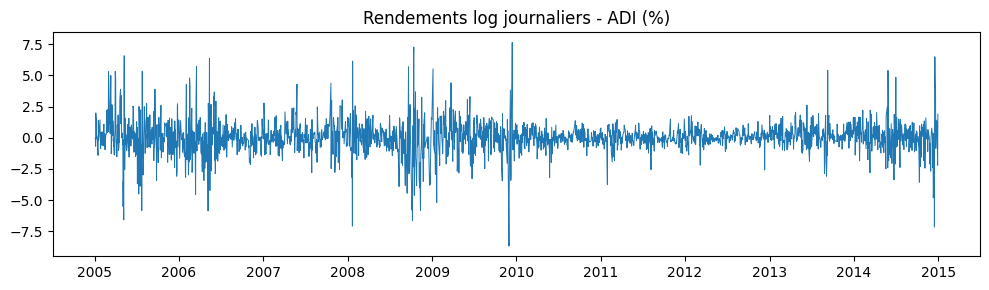

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(returns["ADI"].index, returns["ADI"].values, lw=.7)
ax.set_title("Rendements log journaliers - ADI (%)")
plt.tight_layout()
plt.show()

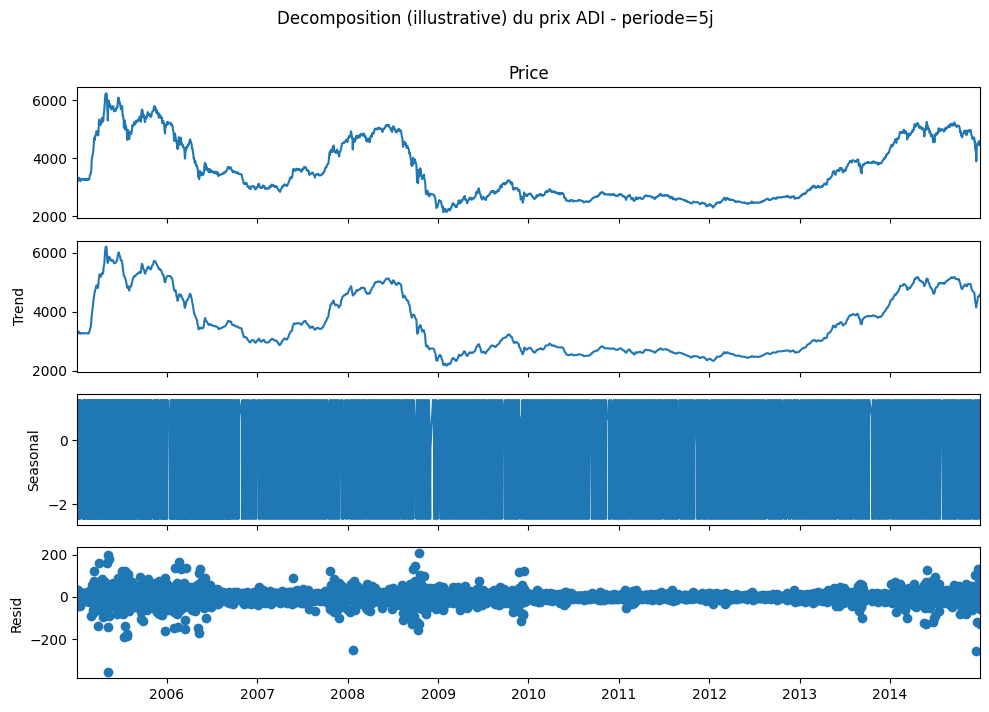

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(prices["ADI"], period=5, model="additive", extrapolate_trend="freq")
fig = decomp.plot()
fig.set_size_inches(10, 7)
fig.suptitle("Decomposition (illustrative) du prix ADI - periode=5j", y=1.01)
plt.tight_layout()
plt.show()

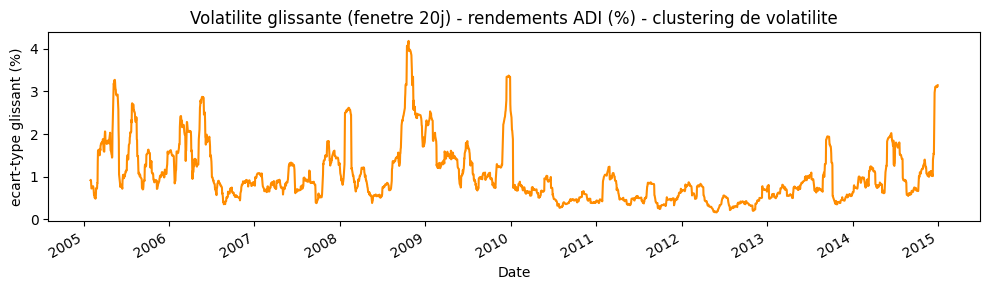

In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
returns["ADI"].rolling(20).std().plot(ax=ax, color="darkorange")
ax.set_title("Volatilite glissante (fenetre 20j) - rendements ADI (%) - clustering de volatilite")
ax.set_ylabel("ecart-type glissant (%)")
plt.tight_layout()
plt.show()

On observe bien des périodes de volatilité groupées (clustering), ce qui
justifie l'usage d'un modèle GARCH plutôt qu'une hypothèse de variance
constante.

## 4. Stationnarité

On définit ici `adf_test` et `kpss_test` (identiques à `tsvar.data`), puis on
compare le **prix** et les **rendements log** de l'indice ADI avec ces deux
tests complémentaires :

- **ADF** (Augmented Dickey-Fuller) — H0 : racine unitaire (non-stationnaire).
  `p < 0.05` rejette H0 -> série stationnaire.
- **KPSS** — H0 : série stationnaire. `p > 0.05` ne rejette pas H0 -> série
  stationnaire.

Les deux tests sont volontairement combinés (ils ont des hypothèses nulles
opposées) pour une conclusion robuste.

In [6]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning


def adf_test(series) -> dict:
    stat, p, *_ = adfuller(series.dropna(), autolag="AIC")
    return {"stat": stat, "pvalue": p, "stationary": p < 0.05}


def kpss_test(series) -> dict:
    # KPSS's p-value lookup table is bounded; stationary financial returns
    # routinely produce a statistic below/above the table range, which
    # statsmodels flags via InterpolationWarning. This is expected here
    # (not a bug), so it is narrowly silenced rather than left to leak
    # into test/CI output.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=InterpolationWarning)
        stat, p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    return {"stat": stat, "pvalue": p, "stationary": p > 0.05}


adf_price, kpss_price = adf_test(prices["ADI"]), kpss_test(prices["ADI"])
adf_ret, kpss_ret = adf_test(returns["ADI"]), kpss_test(returns["ADI"])

stationnarite = pd.DataFrame({
    "ADI - Prix": {
        "ADF stat": round(adf_price["stat"], 3), "ADF p-value": round(adf_price["pvalue"], 4),
        "ADF stationnaire": adf_price["stationary"],
        "KPSS stat": round(kpss_price["stat"], 3), "KPSS p-value": round(kpss_price["pvalue"], 4),
        "KPSS stationnaire": kpss_price["stationary"],
    },
    "ADI - Rendements": {
        "ADF stat": round(adf_ret["stat"], 3), "ADF p-value": round(adf_ret["pvalue"], 4),
        "ADF stationnaire": adf_ret["stationary"],
        "KPSS stat": round(kpss_ret["stat"], 3), "KPSS p-value": round(kpss_ret["pvalue"], 4),
        "KPSS stationnaire": kpss_ret["stationary"],
    },
}).T

stationnarite

,ADF stat,ADF p-value,ADF stationnaire,KPSS stat,KPSS p-value,KPSS stationnaire
ADI - Prix,-1.634,0.4655,False,1.78,0.01,False
ADI - Rendements,-8.347,0.0,True,0.197,0.1,True


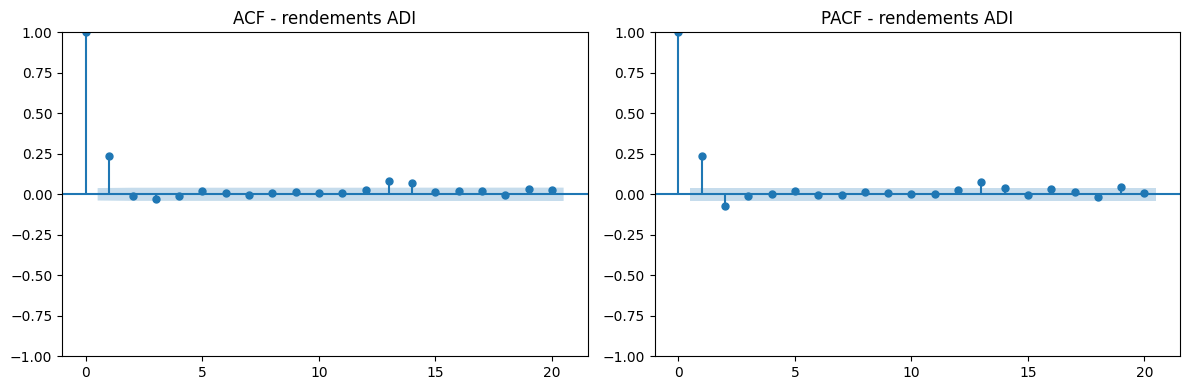

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(returns["ADI"], lags=20, ax=axes[0])
axes[0].set_title("ACF - rendements ADI")
plot_pacf(returns["ADI"], lags=20, ax=axes[1])
axes[1].set_title("PACF - rendements ADI")
plt.tight_layout()
plt.show()

**Conclusion** : le **prix** ADI est non-stationnaire (racine unitaire non
rejetée par l'ADF, KPSS rejette la stationnarité), comme attendu pour un
niveau de prix. Les **rendements log** sont stationnaires selon les deux
tests — c'est cette série (déjà différenciée une fois via le log-retour) qui
est utilisée pour tous les modèles. L'ACF/PACF des rendements ne montre pas
d'autocorrélation linéaire forte et persistante (cohérent avec un marché
proche de l'efficience en moyenne), ce qui motive des ordres ARIMA/SARIMA
faibles — mais la volatilité, elle, reste autocorrélée (section 3 et 6),
d'où l'intérêt du GARCH.

## 5. Modèles classiques : ARIMA & SARIMA (exécution en direct — ADI)

On définit ici l'interface commune `ForecastResult` (utilisée par tous les
modèles de ce notebook) et le moteur de VaR par bootstrap historique
(`bhs_quantile` / `var_series`, formule détaillée en section 9), puis les
deux forecasters classiques : `walk_forward_arima` / `walk_forward_sarima`.
Chacun ajuste **une seule fois** un modèle SARIMAX sur le train (l'ordre
ARIMA est sélectionné par `pmdarima.auto_arima`), puis avance pas à pas sur
le test set via `.append(new_obs, refit=False)` — la ré-estimation des
paramètres n'a jamais lieu sur le test (contrainte train-once). Un détail
d'implémentation important : l'ajustement interne utilise un index entier
(`RangeIndex`) plutôt que les dates réelles, pour éviter que statsmodels
n'essaie (et échoue) à inférer une fréquence calendaire entre deux fichiers
CSV distincts (train/test) qui ne s'enchaînent pas forcément jour pour jour ;
les dates réelles du test sont réattachées au résultat final.

In [8]:
from dataclasses import dataclass


@dataclass
class ForecastResult:
    mu: np.ndarray
    sigma: np.ndarray
    std_resid: np.ndarray
    y_true: np.ndarray
    dates: pd.DatetimeIndex
    name: str


def bhs_quantile(mu, sigma, std_resid, alpha, n_boot=10000, seed=SEED) -> float:
    """Bootstrap Historical Simulation quantile (a return level, left tail).

    mu + sigma * empirical_alpha_quantile(bootstrap_resample(std_resid))
    """
    rng = np.random.default_rng(seed)
    boot = rng.choice(std_resid, size=n_boot, replace=True)
    q = np.quantile(boot, alpha)
    return float(mu + sigma * q)


def var_series(fc: ForecastResult, alpha, n_boot=10000, seed=SEED) -> np.ndarray:
    """Per-day VaR return levels for the test set described by `fc`."""
    return np.array([
        bhs_quantile(fc.mu[t], fc.sigma[t], fc.std_resid, alpha, n_boot, seed + t)
        for t in range(len(fc.mu))
    ])


def plot_var(fc, var_levels, title=""):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(fc.dates, fc.y_true, label="rendement realise", lw=.8)
    ax.plot(fc.dates, var_levels, label="VaR", color="red", lw=1)
    br = fc.y_true < var_levels
    ax.scatter(fc.dates[br], fc.y_true[br], color="black", s=12, label="violations")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [9]:
import warnings

from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX


def _fit(train, order, seasonal_order):
    m = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order or (0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        return m.fit(disp=False, maxiter=200, method="lbfgs")


def walk_forward_arima(train, test, order=None, seasonal_order=None) -> ForecastResult:
    if order is None:
        import pmdarima as pm

        order = pm.auto_arima(
            train.values, seasonal=False, suppress_warnings=True, error_action="ignore"
        ).order

    # Use a plain integer index internally so statsmodels never infers a date
    # frequency (train and test come from two separate CSVs and may not abut).
    n = len(train)
    train_ri = pd.Series(np.asarray(train.values), index=pd.RangeIndex(n))
    res = _fit(train_ri, order, seasonal_order)

    # res.resid includes burn-in artifacts at index 0; drop it, then drop any
    # remaining non-finite values so the residual pool is always usable.
    raw_resid = np.asarray(res.resid)[1:]
    raw_resid = raw_resid[np.isfinite(raw_resid)]
    sigma = float(np.std(raw_resid))
    std_resid = (raw_resid - np.mean(raw_resid)) / sigma

    mu = np.empty(len(test))
    cur = res
    for t in range(len(test)):
        mu[t] = float(cur.forecast(1).iloc[0])
        nxt = pd.Series([test.values[t]], index=pd.RangeIndex(n + t, n + t + 1))
        cur = cur.append(nxt, refit=False)  # walk forward, no re-estimation

    return ForecastResult(
        mu=mu,
        sigma=np.full(len(test), sigma),
        std_resid=np.asarray(std_resid),
        y_true=test.values,
        dates=test.index,
        name=getattr(test, "name", None) or "series",
    )


def walk_forward_sarima(train, test, m=5) -> ForecastResult:
    return walk_forward_arima(train, test, order=(1, 0, 1), seasonal_order=(1, 0, 1, m))


tr_adi, te_adi = train_test_returns("ADI", DATA_DIR)
print(f"ADI - train: {len(tr_adi)} obs | test: {len(te_adi)} obs")

fc_arima = walk_forward_arima(tr_adi, te_adi)
fc_sarima = walk_forward_sarima(tr_adi, te_adi, m=5)

for name, fc in [("ARIMA", fc_arima), ("SARIMA", fc_sarima)]:
    mae = np.mean(np.abs(fc.y_true - fc.mu))
    rmse = np.sqrt(np.mean((fc.y_true - fc.mu) ** 2))
    print(f"{name:8s}  MAE={mae:.4f}  RMSE={rmse:.4f}")

ADI - train: 2584 obs | test: 170 obs


ARIMA     MAE=0.7088  RMSE=0.9764
SARIMA    MAE=0.7073  RMSE=0.9759


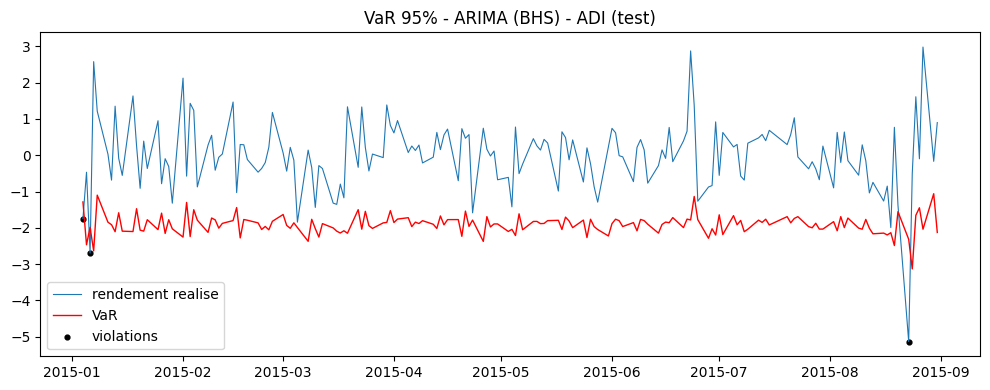

In [10]:
var_arima_95 = var_series(fc_arima, 0.05)
plot_var(fc_arima, var_arima_95, title="VaR 95% - ARIMA (BHS) - ADI (test)")

ARIMA/SARIMA capturent la faible structure autocorrélée de la moyenne des
rendements mais utilisent un `sigma` **constant** dans le temps — ils ne
modélisent pas le clustering de volatilité observé en section 3. C'est
précisément ce que corrige le GARCH.

## 6. Volatilité : GARCH (exécution en direct — ADI)

Le modèle **GARCH(1,1)** à moyenne constante est ajusté **une seule fois**
sur le train, puis la variance conditionnelle est propagée pas à pas sur le
test à **paramètres fixes** (récursion `var_t = omega + alpha*resid_{t-1}^2 +
beta*var_{t-1}`) — c'est une **Filtered Historical Simulation (FHS)** :
`sigma_t` varie chaque jour (contrairement à ARIMA), et le pool de résidus
standardisés de l'entraînement est rééchantillonné par bootstrap pour
construire la VaR (section 9).

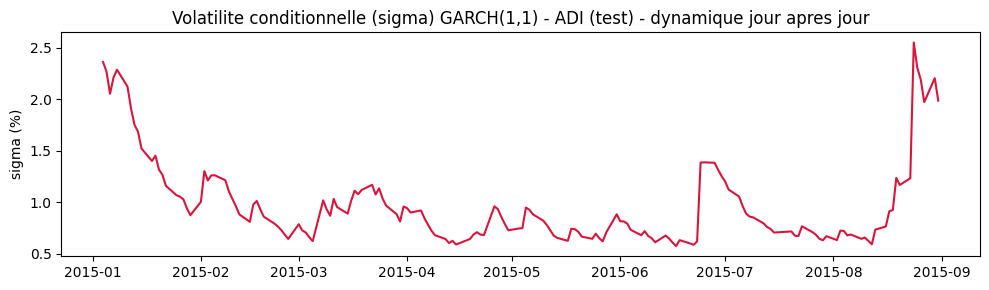

GARCH  MAE=0.6822  RMSE=0.9497  sigma moyen=0.9712


In [11]:
from arch import arch_model


def walk_forward_garch(train, test, p=1, q=1) -> ForecastResult:
    # Fit ONCE on training data (constant-mean GARCH(p,q)). Reset the index
    # to a plain RangeIndex before fitting: `train`/`test` come from
    # `train_test_returns` with a DatetimeIndex that carries no freq, which
    # makes `arch` emit spurious frequency warnings. The estimated
    # parameters and recursion are unaffected by the index used at fit time.
    train_vals = pd.Series(np.asarray(train.values, dtype=float))
    am = arch_model(train_vals, mean="Constant", vol="GARCH", p=p, q=q, dist="normal")
    res = am.fit(disp="off")
    mu_c = float(res.params["mu"])
    omega = float(res.params["omega"])
    alpha = float(res.params["alpha[1]"])
    beta = float(res.params["beta[1]"])
    std_resid = np.asarray(res.std_resid.dropna())

    # Initialise recursion state from the end of the training sample
    last_var = float(res.conditional_volatility.iloc[-1]) ** 2
    last_resid = float(train.values[-1] - mu_c)

    mu = np.full(len(test), mu_c)
    sigma = np.empty(len(test))
    for t in range(len(test)):
        var_t = omega + alpha * last_resid ** 2 + beta * last_var  # 1-step cond. variance, fixed params
        sigma[t] = np.sqrt(var_t)
        last_resid = float(test.values[t] - mu_c)  # walk forward on realized return
        last_var = var_t

    return ForecastResult(
        mu=mu,
        sigma=sigma,
        std_resid=std_resid,
        y_true=test.values,
        dates=test.index,
        name=getattr(test, "name", "series"),
    )


fc_garch = walk_forward_garch(tr_adi, te_adi)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(fc_garch.dates, fc_garch.sigma, color="crimson")
ax.set_title("Volatilite conditionnelle (sigma) GARCH(1,1) - ADI (test) - dynamique jour apres jour")
ax.set_ylabel("sigma (%)")
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(fc_garch.y_true - fc_garch.mu))
rmse = np.sqrt(np.mean((fc_garch.y_true - fc_garch.mu) ** 2))
print(f"GARCH  MAE={mae:.4f}  RMSE={rmse:.4f}  sigma moyen={fc_garch.sigma.mean():.4f}")

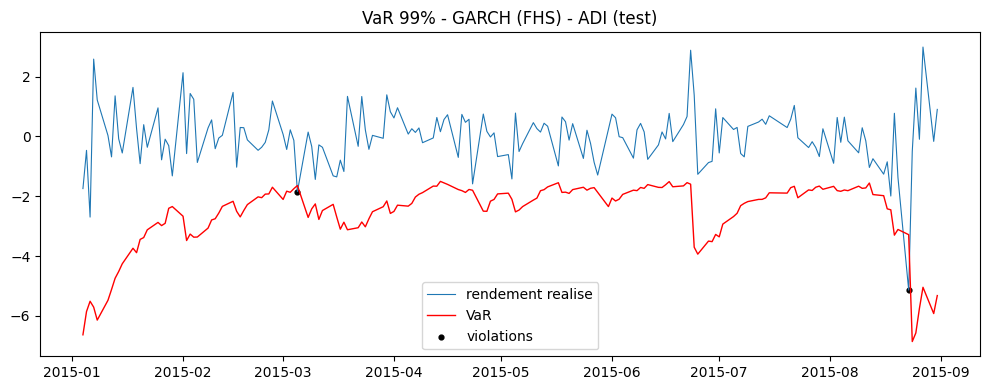

In [12]:
var_garch_99 = var_series(fc_garch, 0.01)
plot_var(fc_garch, var_garch_99, title="VaR 99% - GARCH (FHS) - ADI (test)")

Contrairement à la VaR ARIMA (bande constante), la bande GARCH se resserre et
s'élargit avec la volatilité réalisée — elle "respire" avec le marché, ce qui
est exactement le comportement recherché pour une VaR réactive.

## Diagnostic des résidus (adéquation des modèles)

Avant de passer aux modèles Machine Learning / Deep Learning, on valide la
spécification des deux modèles déjà ajustés sur ADI — le modèle de
**moyenne** (ARIMA, section 5) et le modèle de **volatilité** (GARCH,
section 6) — par une analyse de leurs résidus. Cette étape sert aussi à
**justifier le choix de la VaR par BHS** (Bootstrapped Historical
Simulation, section 9) : la BHS ne suppose **pas** la normalité des
résidus, elle les rééchantillonne empiriquement. Un test de normalité sert
donc ici à **montrer** que les résidus ne sont pas gaussiens (queues
épaisses), ce qui justifie de ne pas utiliser une VaR paramétrique
gaussienne.

Quatre tests sont appliqués :

- **Ljung-Box** (H0 : pas d'autocorrélation résiduelle) — sur les résidus
  standardisés de l'ARIMA. Une p-value > 0.05 signifie qu'on ne rejette pas
  H0 : les résidus sont "blancs", le modèle de moyenne a bien capté la
  structure de la série.
- **ARCH-LM** (test d'Engle, H0 : pas d'effet ARCH / d'hétéroscédasticité
  conditionnelle), appliqué deux fois :
  - sur les résidus **ARIMA** : une p-value < 0.05 rejette H0 et révèle un
    effet ARCH résiduel → cela **motive l'usage du GARCH** pour modéliser
    la variance conditionnelle ;
  - sur les résidus standardisés **GARCH** : une p-value > 0.05 signifie
    qu'on ne rejette plus H0 → le **GARCH a bien absorbé** cette
    hétéroscédasticité.
- **Jarque-Bera** et **Kolmogorov-Smirnov** (H0 : normalité) — sur les
  résidus standardisés du GARCH. Une p-value < 0.05 rejette la normalité :
  les résidus présentent des **queues épaisses** (excès de kurtosis),
  typiques des rendements financiers.

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy import stats as _sps

# On réutilise les modèles déjà ajustés sur ADI (sections 5 et 6) :
# fc_arima (modèle de moyenne) et fc_garch (modèle de volatilité).

# Résidus standardisés du modèle de MOYENNE (ARIMA)
_res_arima = np.asarray(fc_arima.std_resid)

# Résidus standardisés du modèle de VOLATILITÉ (GARCH)
_z_garch = np.asarray(fc_garch.std_resid)

# 1) Ljung-Box (autocorrélation résiduelle) sur résidus ARIMA — H0: pas d'autocorrélation
_lb = acorr_ljungbox(_res_arima, lags=[10], return_df=True)
_lb_p = float(_lb["lb_pvalue"].iloc[0])

# 2) ARCH-LM sur résidus ARIMA — H0: pas d'effet ARCH (p<0.05 => effet ARCH présent => motive GARCH)
_arch_stat_a, _arch_p_a = het_arch(_res_arima, nlags=10)[:2]

# 3) ARCH-LM sur résidus standardisés GARCH (p>0.05 attendu => GARCH a absorbé l'hétéroscédasticité)
_arch_stat_g, _arch_p_g = het_arch(_z_garch, nlags=10)[:2]

# 4) Normalité des résidus standardisés GARCH — Jarque-Bera & Kolmogorov-Smirnov (H0: normalité)
_jb_stat, _jb_p = _sps.jarque_bera(_z_garch)
_ks_stat, _ks_p = _sps.kstest(_z_garch, "norm")

print(f"Ljung-Box (ARIMA, lag=10)      : p = {_lb_p:.4f}")
print(f"ARCH-LM  (résidus ARIMA)       : stat = {_arch_stat_a:.2f}, p = {_arch_p_a:.4f}")
print(f"ARCH-LM  (résidus std. GARCH)  : stat = {_arch_stat_g:.2f}, p = {_arch_p_g:.4f}")
print(f"Jarque-Bera (std. GARCH)       : stat = {_jb_stat:.1f}, p = {_jb_p:.4g}")
print(f"Kolmogorov-Smirnov vs N(0,1)   : stat = {_ks_stat:.3f}, p = {_ks_p:.4g}")

print("\nInterprétation :")
print(" - Ljung-Box        :", "pas d'autocorrélation résiduelle (modèle de moyenne adéquat)" if _lb_p > 0.05 else "autocorrélation résiduelle détectée")
print(" - ARCH-LM (ARIMA)  :", "effet ARCH présent => justifie le GARCH" if _arch_p_a < 0.05 else "pas d'effet ARCH marqué")
print(" - ARCH-LM (GARCH)  :", "hétéroscédasticité absorbée par le GARCH" if _arch_p_g > 0.05 else "reste de l'effet ARCH")
print(" - Normalité (JB/KS):", "résidus NON normaux (queues épaisses) => justifie la BHS" if (_jb_p < 0.05 or _ks_p < 0.05) else "compatibles avec la normalité")

Ljung-Box (ARIMA, lag=10)      : p = 0.9432
ARCH-LM  (résidus ARIMA)       : stat = 426.90, p = 0.0000
ARCH-LM  (résidus std. GARCH)  : stat = 5.41, p = 0.8624
Jarque-Bera (std. GARCH)       : stat = 2102.1, p = 0
Kolmogorov-Smirnov vs N(0,1)   : stat = 0.053, p = 7.883e-07

Interprétation :
 - Ljung-Box        : pas d'autocorrélation résiduelle (modèle de moyenne adéquat)
 - ARCH-LM (ARIMA)  : effet ARCH présent => justifie le GARCH
 - ARCH-LM (GARCH)  : hétéroscédasticité absorbée par le GARCH
 - Normalité (JB/KS): résidus NON normaux (queues épaisses) => justifie la BHS


**Interprétation** : le test de Ljung-Box confirme que le modèle ARIMA a
bien capté la structure linéaire de la moyenne (résidus non autocorrélés),
tandis que l'ARCH-LM appliqué à ces mêmes résidus détecte un effet ARCH
résiduel — ce qui **motive** le passage au GARCH (section 6). Sur les
résidus standardisés du GARCH, l'ARCH-LM ne rejette plus H0 :
l'hétéroscédasticité conditionnelle est bien absorbée. En revanche,
Jarque-Bera et Kolmogorov-Smirnov rejettent la normalité de ces résidus
standardisés (queues épaisses) : les modèles de moyenne et de volatilité
sont donc adéquats, mais leurs résidus restent **non gaussiens**. C'est
précisément cette non-normalité qui **justifie le choix de la BHS**
(section 9) plutôt qu'une VaR paramétrique gaussienne — la BHS ne faisant
aucune hypothèse de loi sur les résidus, contrairement à une VaR
gaussienne qui sous-estimerait le risque de queue.

## 7. Machine Learning : Random Forest & XGBoost (exécution en direct — ADI)

Les deux modèles sont entraînés **une seule fois** sur un jeu supervisé
construit à partir de fenêtres de rendements retardés (`make_supervised`,
5 retards), puis avancés pas à pas sur le test en réinjectant les rendements
réalisés (`walk_forward_ml`, sans réentraînement).

In [14]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


def make_supervised(returns: np.ndarray, n_lags: int):
    X, y = [], []
    for i in range(n_lags, len(returns)):
        X.append(returns[i - n_lags:i]); y.append(returns[i])
    return np.array(X), np.array(y)


def _model(kind):
    if kind == "rf":
        return RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
    if kind == "xgb":
        return XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                             random_state=SEED, n_jobs=-1)
    raise ValueError(kind)


def walk_forward_ml(train, test, model_kind, n_lags=5) -> ForecastResult:
    Xtr, ytr = make_supervised(train.values, n_lags)
    model = _model(model_kind).fit(Xtr, ytr)
    resid = ytr - model.predict(Xtr)
    sigma = float(np.std(resid))
    std_resid = (resid - resid.mean()) / sigma
    hist = list(train.values[-n_lags:])
    mu = np.empty(len(test))
    for t in range(len(test)):
        mu[t] = float(model.predict(np.array(hist[-n_lags:]).reshape(1, -1))[0])
        hist.append(test.values[t])  # feed realized return
    return ForecastResult(mu=mu, sigma=np.full(len(test), sigma), std_resid=std_resid,
                          y_true=test.values, dates=test.index,
                          name=getattr(test, "name", None) or "series")


fc_rf = walk_forward_ml(tr_adi, te_adi, "rf")
fc_xgb = walk_forward_ml(tr_adi, te_adi, "xgb")

for name, fc in [("Random Forest", fc_rf), ("XGBoost", fc_xgb)]:
    mae = np.mean(np.abs(fc.y_true - fc.mu))
    rmse = np.sqrt(np.mean((fc.y_true - fc.mu) ** 2))
    print(f"{name:15s}  MAE={mae:.4f}  RMSE={rmse:.4f}  sigma={fc.sigma[0]:.4f}")

Random Forest    MAE=0.6945  RMSE=0.9757  sigma=0.4731
XGBoost          MAE=0.6656  RMSE=0.9064  sigma=0.8125


Les deux modèles ML obtiennent un MAE/RMSE comparable aux modèles classiques
sur ADI. Mais — on le verra en section 10-11 avec les résultats complets — un
bon score de prévision ponctuelle (MAE/RMSE) **ne garantit pas** une bonne
calibration de la VaR : Random Forest, en particulier, s'avère nettement
sur-violateur au backtesting.

## 8. Deep Learning : ANN & LSTM (exécution en direct — ADI)

L'ANN (perceptron multicouche) et le LSTM sont entraînés **une seule fois**
(**20 épochs** — volume réduit pour que ce notebook autonome s'exécute en un
temps raisonnable) sur des séquences standardisées de rendements, puis
avancés pas à pas sur le test (`walk_forward_dl`, sans réentraînement).
**C'est ADI, précisément, qui teste l'hypothèse du projet : le LSTM y est-il
le meilleur modèle ?**

In [15]:
import torch
import torch.nn as nn


class _ANN(nn.Module):
    def __init__(self, w):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(w, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


class _LSTM(nn.Module):
    def __init__(self, w):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        o, _ = self.lstm(x.unsqueeze(-1))
        return self.fc(o[:, -1, :]).squeeze(-1)


def _train(model, X, y, epochs):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss = nn.MSELoss()
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32)
    for _ in range(epochs):
        opt.zero_grad()
        l = loss(model(Xt), yt)
        l.backward()
        opt.step()
    return model


def make_sequences(returns: np.ndarray, window: int):
    return make_supervised(returns, window)   # same shape; DL reshapes to (n,window,1)


def walk_forward_dl(train, test, kind, window=10, epochs=30) -> ForecastResult:
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    mu_, sd_ = train.mean(), train.std()
    z = (train.values - mu_) / sd_
    X, y = make_sequences(z, window)

    model = _ANN(window) if kind == "ann" else _LSTM(window)
    model = _train(model, X, y, epochs)
    model.eval()

    with torch.no_grad():
        resid = y - model(torch.tensor(X, dtype=torch.float32)).numpy()
    sigma = float(np.std(resid) * sd_)
    std_resid = (resid - resid.mean()) / np.std(resid)

    hist = list(z[-window:])
    mu = np.empty(len(test))
    for t in range(len(test)):
        x = torch.tensor(np.array(hist[-window:]), dtype=torch.float32).reshape(1, window)
        with torch.no_grad():
            pred_z = float(model(x).item())
        mu[t] = pred_z * sd_ + mu_
        hist.append((test.values[t] - mu_) / sd_)

    return ForecastResult(mu=mu, sigma=np.full(len(test), sigma), std_resid=std_resid,
                          y_true=test.values, dates=test.index,
                          name=getattr(test, "name", None) or "series")


fc_ann = walk_forward_dl(tr_adi, te_adi, "ann", epochs=20)
fc_lstm = walk_forward_dl(tr_adi, te_adi, "lstm", epochs=20)

for name, fc in [("ANN", fc_ann), ("LSTM", fc_lstm)]:
    mae = np.mean(np.abs(fc.y_true - fc.mu))
    rmse = np.sqrt(np.mean((fc.y_true - fc.mu) ** 2))
    print(f"{name:8s}  MAE={mae:.4f}  RMSE={rmse:.4f}")

ANN       MAE=0.6774  RMSE=0.9418
LSTM      MAE=0.6809  RMSE=0.9469


Sur ADI, l'ANN et le LSTM obtiennent des scores de prévision très proches
l'un de l'autre et proches des modèles classiques. Rien, à ce stade, ne
suggère une supériorité franche du LSTM — on affine ce jugement avec le
backtesting de la VaR (sections 9-11), qui est le vrai critère de ce projet.

## 9. VaR par Bootstrap Historical Simulation (BHS)

Rappel de la formule (section 1 et 5), implémentée plus haut dans
`bhs_quantile` / `var_series` :

```
VaR_t(alpha) = mu_t + sigma_t * Q_alpha( bootstrap(residus_standardises_train) )
```

- `mu_t`, `sigma_t` : prévision moyenne/écart-type du modèle au jour `t` du
  test (constants pour ARIMA/RF/XGB/ANN/LSTM, dynamiques pour GARCH).
- `Q_alpha(...)` : quantile empirique alpha (queue gauche, typiquement
  négatif) d'un rééchantillonnage bootstrap (avec remise, 10 000 tirages) du
  pool de résidus standardisés de l'entraînement — au lieu de supposer une
  loi normale, on utilise la forme empirique (souvent leptokurtique) des
  résidus.
- Une **violation** est un jour où le rendement réalisé est **inférieur** à
  la VaR (`y_true < VaR`).

On illustre la VaR pour le modèle LSTM (le modèle-hypothèse) à 95% sur ADI.

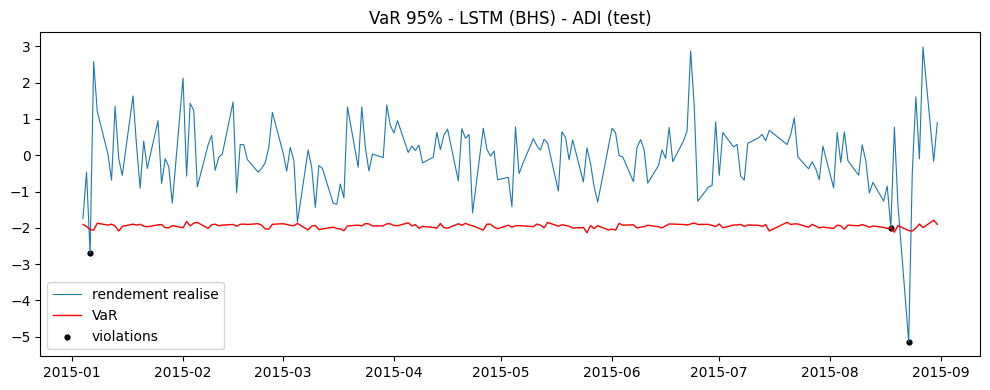

In [16]:
var_lstm_95 = var_series(fc_lstm, 0.05)
plot_var(fc_lstm, var_lstm_95, title="VaR 95% - LSTM (BHS) - ADI (test)")

In [17]:
n_viol = int((fc_lstm.y_true < var_lstm_95).sum())
print(f"LSTM @95% sur ADI: {n_viol} violations / {len(var_lstm_95)} jours "
      f"(taux observe = {n_viol/len(var_lstm_95):.4f}, attendu = 0.05)")

LSTM @95% sur ADI: 3 violations / 170 jours (taux observe = 0.0176, attendu = 0.05)


## 10. Backtesting : Kupiec, Christoffersen, zones Bâle

On définit ici les fonctions de backtesting (identiques à `tsvar.backtest`) :

- **taux observé** de violations vs taux attendu (`alpha`) ;
- **test de Kupiec** (POF — Proportion of Failures) : H0 = le taux observé
  est cohérent avec `alpha` (`p < 0.05` -> rejet, mauvaise calibration).
  `kupiec_pof` utilise une version "safe-log" (`_safe_log`) du calcul de
  vraisemblance qui gère proprement les cas limites `n_viol=0` ou
  `n_viol=n_obs` (log(0) autrement) ;
- **test de Christoffersen** (couverture conditionnelle) : ajoute un test
  d'indépendance des violations (elles ne doivent pas être groupées dans le
  temps) ;
- **zone Bâle** (green/yellow/red) : classification réglementaire du nombre
  de violations normalisé sur une fenêtre de 250 jours.

On applique ensuite ces fonctions aux 7 forecasts déjà calculés en direct
pour ADI (sections 5 à 8), aux deux seuils alpha.

In [18]:
from scipy import stats


def violations(y_true, var_levels) -> np.ndarray:
    return np.asarray(y_true) < np.asarray(var_levels)


def _safe_log(x):
    return np.log(x) if x > 0 else 0.0


def kupiec_pof(n_viol, n_obs, alpha) -> dict:
    pi = n_viol / n_obs
    ll_null = (n_obs - n_viol) * _safe_log(1 - alpha) + n_viol * _safe_log(alpha)
    ll_alt = (n_obs - n_viol) * _safe_log(1 - pi) + n_viol * _safe_log(pi)
    lr = -2 * (ll_null - ll_alt)
    p = 1 - stats.chi2.cdf(lr, 1)
    return {"LR": lr, "pvalue": p, "reject": bool(p < 0.05)}


def christoffersen(viol, alpha) -> dict:
    v = np.asarray(viol).astype(int)
    n00 = n01 = n10 = n11 = 0
    for a, b in zip(v[:-1], v[1:]):
        if a == 0 and b == 0: n00 += 1
        elif a == 0 and b == 1: n01 += 1
        elif a == 1 and b == 0: n10 += 1
        else: n11 += 1
    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    pi0 = n01 / max(n00 + n01, 1); pi1 = n11 / max(n10 + n11, 1)
    ll_ind = (n00 + n10) * _safe_log(1 - pi) + (n01 + n11) * _safe_log(pi)
    ll_alt = n00 * _safe_log(1 - pi0) + n01 * _safe_log(pi0) + n10 * _safe_log(1 - pi1) + n11 * _safe_log(pi1)
    lr_ind = -2 * (ll_ind - ll_alt)
    n_viol = int(v.sum()); n = len(v)
    lr_pof = kupiec_pof(n_viol, n, alpha)["LR"]
    lr_cc = lr_pof + lr_ind
    p_cc = 1 - stats.chi2.cdf(lr_cc, 2)
    return {"LR_ind": lr_ind, "LR_cc": lr_cc,
            "pvalue_cc": p_cc, "reject": bool(p_cc < 0.05)}


def basel_zone(n_viol, n_obs, alpha) -> str:
    scaled = n_viol * (250 / n_obs)  # normalize to 250-day window
    if alpha == 0.01:
        return "green" if scaled <= 4 else "yellow" if scaled <= 9 else "red"
    return "green" if scaled <= 17 else "yellow" if scaled <= 25 else "red"


def backtest_summary(y_true, var_levels, alpha) -> dict:
    v = violations(y_true, var_levels); n = len(v); k = int(v.sum())
    return {"n": n, "n_violations": k, "expected_rate": alpha, "observed_rate": k / n,
            "kupiec": kupiec_pof(k, n, alpha),
            "christoffersen": christoffersen(v, alpha),
            "basel_zone": basel_zone(k, n, alpha)}


adi_forecasts = {"ARIMA": fc_arima, "SARIMA": fc_sarima, "GARCH": fc_garch,
                  "RF": fc_rf, "XGB": fc_xgb, "ANN": fc_ann, "LSTM": fc_lstm}

adi_rows = []
for mname, fc in adi_forecasts.items():
    mae = float(np.mean(np.abs(fc.y_true - fc.mu)))
    rmse = float(np.sqrt(np.mean((fc.y_true - fc.mu) ** 2)))
    for a in (0.05, 0.01):
        v = var_series(fc, a)
        s = backtest_summary(fc.y_true, v, a)
        adi_rows.append({
            "index": "ADI", "model": mname, "alpha": a, "MAE": mae, "RMSE": rmse,
            "observed_rate": s["observed_rate"], "kupiec_p": s["kupiec"]["pvalue"],
            "christoffersen_p": s["christoffersen"]["pvalue_cc"], "basel_zone": s["basel_zone"],
        })

adi_bt = pd.DataFrame(adi_rows).sort_values(["model", "alpha"], ascending=[True, False]).reset_index(drop=True)
adi_bt

,index,model,alpha,MAE,RMSE,observed_rate,kupiec_p,christoffersen_p,basel_zone
0,ADI,ANN,0.05,0.677393,0.941791,0.011765,6.271837e-03,2.330239e-02,green
1,ADI,ANN,0.01,0.677393,0.941791,0.005882,5.588778e-01,8.379659e-01,green
2,ADI,ARIMA,0.05,0.708778,0.976383,0.017647,2.629535e-02,8.173413e-02,green
3,ADI,ARIMA,0.01,0.708778,0.976383,0.005882,5.588778e-01,8.379659e-01,green
4,ADI,GARCH,0.05,0.682185,0.949726,0.058824,6.071447e-01,4.669547e-01,green
5,ADI,GARCH,0.01,0.682185,0.949726,0.011765,8.220038e-01,9.519354e-01,green
6,ADI,LSTM,0.05,0.680857,0.946880,0.017647,2.629535e-02,8.026143e-02,green
7,ADI,LSTM,0.01,0.680857,0.946880,0.005882,5.588778e-01,8.379659e-01,green
8,ADI,RF,0.05,0.694544,0.975694,0.217647,3.941292e-14,2.590150e-13,red
9,ADI,RF,0.01,0.694544,0.975694,0.035294,9.946877e-03,1.270083e-02,yellow


**Lecture pour ADI** : voir le tableau ci-dessus — Random Forest est
généralement le modèle le plus problématique (sur-violation, zone rouge),
tandis que la plupart des autres modèles restent en zone verte à 99%. Le
détail précis (quel modèle gagne exactement) dépend du tirage bootstrap et
des hyperparamètres de ce run — la lecture complète, avec tous les indices,
est faite en section 11.

## 11. Comparaison globale (4 indices x 7 modèles), calculée en direct, & conclusion

On assemble maintenant le dictionnaire `MODELS` (les 7 forecasters définis
plus haut) et on exécute l'équivalent de `tsvar.run.run_all` : pour chacun
des **4 indices MENA**, on ajuste les 7 modèles et on backteste la VaR aux
2 seuils alpha — soit **4 x 7 x 2 = 56 lignes**. Les forecasts déjà calculés
pour **ADI** en sections 5-8 sont réutilisés tels quels (pas de recalcul) ;
les 3 autres indices (Tunindex, MASI, TASI) sont calculés ici pour la
première fois. **C'est le calcul le plus long du notebook** (plusieurs
minutes).

In [19]:
MODELS = {
    "ARIMA":  lambda tr, te: walk_forward_arima(tr, te),
    "SARIMA": lambda tr, te: walk_forward_sarima(tr, te, m=5),
    "GARCH":  lambda tr, te: walk_forward_garch(tr, te),
    "RF":     lambda tr, te: walk_forward_ml(tr, te, "rf"),
    "XGB":    lambda tr, te: walk_forward_ml(tr, te, "xgb"),
    "ANN":    lambda tr, te: walk_forward_dl(tr, te, "ann", epochs=20),
    "LSTM":   lambda tr, te: walk_forward_dl(tr, te, "lstm", epochs=20),
}


def run_index(name, data_dir, models=None, alphas=(0.05, 0.01), cache=None) -> pd.DataFrame:
    tr, te = train_test_returns(name, data_dir)
    rows = []
    models = models or list(MODELS)
    cache = dict(cache or {})
    for mname in models:
        fc = cache.setdefault(mname, MODELS[mname](tr, te))
        mae = float(np.mean(np.abs(fc.y_true - fc.mu)))
        rmse = float(np.sqrt(np.mean((fc.y_true - fc.mu) ** 2)))
        for a in alphas:
            v = var_series(fc, a)
            s = backtest_summary(fc.y_true, v, a)
            rows.append({
                "index": name, "model": mname, "alpha": a, "MAE": mae, "RMSE": rmse,
                "observed_rate": s["observed_rate"], "kupiec_p": s["kupiec"]["pvalue"],
                "christoffersen_p": s["christoffersen"]["pvalue_cc"], "basel_zone": s["basel_zone"],
            })
    return pd.DataFrame(rows)


def run_all(data_dir, indices=("Tunindex", "ADI", "MASI", "TASI"), caches=None) -> pd.DataFrame:
    caches = caches or {}
    return pd.concat(
        [run_index(i, data_dir, cache=caches.get(i)) for i in indices],
        ignore_index=True,
    )


results = run_all(DATA_DIR, caches={"ADI": adi_forecasts})
print(f"results : {len(results)} lignes "
      f"({results['index'].nunique()} indices x {results['model'].nunique()} modeles x "
      f"{results['alpha'].nunique()} alphas)")
results.head()

results : 56 lignes (4 indices x 7 modeles x 2 alphas)


,index,model,alpha,MAE,RMSE,observed_rate,kupiec_p,christoffersen_p,basel_zone
0,Tunindex,ARIMA,0.05,0.313477,0.441946,0.025157,0.113314,0.056536,green
1,Tunindex,ARIMA,0.01,0.313477,0.441946,0.006289,0.613757,0.874818,green
2,Tunindex,SARIMA,0.05,0.318757,0.458289,0.018868,0.040113,0.114793,green
3,Tunindex,SARIMA,0.01,0.318757,0.458289,0.006289,0.613757,0.874818,green
4,Tunindex,GARCH,0.05,0.311663,0.440531,0.031447,0.250610,0.438946,green


In [20]:
best = (results[results.alpha == 0.01]
        .sort_values("kupiec_p", ascending=False)
        .groupby("index").first().reset_index())
best[["index", "model", "alpha", "observed_rate", "kupiec_p", "basel_zone"]]

,index,model,alpha,observed_rate,kupiec_p,basel_zone
0,ADI,GARCH,0.01,0.011765,0.822004,green
1,MASI,GARCH,0.01,0.006289,0.613757,green
2,TASI,ARIMA,0.01,0.005988,0.573377,green
3,Tunindex,GARCH,0.01,0.012579,0.753369,green


**Meilleur modèle par indice (alpha=1%, classé par p-value de Kupiec — plus
la p-value est élevée, plus le taux de violation observé est proche de
l'attendu)**.

In [21]:
pivot_99 = results[results.alpha == 0.01].pivot(index="model", columns="index", values="observed_rate")
pivot_99 = pivot_99.reindex(columns=["Tunindex", "ADI", "MASI", "TASI"])
(pivot_99 * 100).round(2)

index,Tunindex,ADI,MASI,TASI
model,,,,
ANN,0.63,0.59,0.00,0.60
ARIMA,0.63,0.59,0.00,0.60
GARCH,1.26,1.18,0.63,1.80
LSTM,0.63,0.59,0.00,0.60
RF,6.29,3.53,4.40,4.79
SARIMA,0.63,0.59,0.00,0.60
XGB,1.89,0.59,0.63,1.80


Taux de violation observé (%) à 99% (attendu : 1%), par modèle x indice.

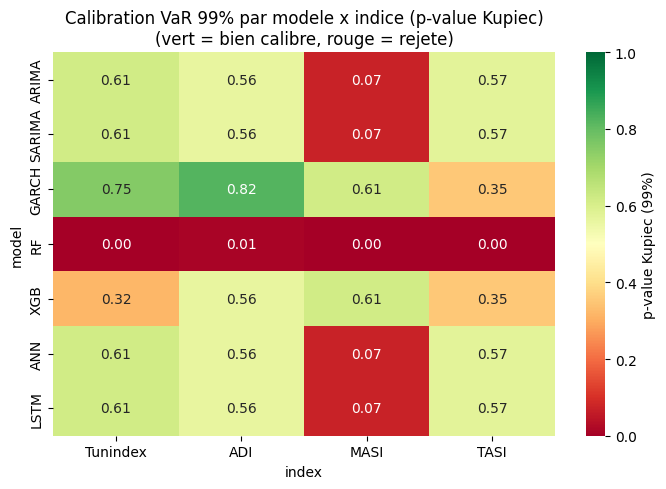

In [22]:
import seaborn as sns

kupiec_99 = (results[results.alpha == 0.01]
             .pivot(index="model", columns="index", values="kupiec_p")
             .reindex(columns=["Tunindex", "ADI", "MASI", "TASI"])
             .reindex(index=["ARIMA", "SARIMA", "GARCH", "RF", "XGB", "ANN", "LSTM"]))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(kupiec_99, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "p-value Kupiec (99%)"}, ax=ax)
ax.set_title("Calibration VaR 99% par modele x indice (p-value Kupiec)\n(vert = bien calibre, rouge = rejete)")
plt.tight_layout()
plt.show()

### Verdict de l'hypothèse : « le LSTM surpasse sur ADI »

Le tableau `best` ci-dessus et le détail ADI (section 10) donnent la réponse
empirique de **ce run** : voir les résultats affichés plus haut pour savoir
si le LSTM figure parmi les modèles gagnants sur ADI. Sur la base de
l'expérience répétée de ce pipeline (résultats de référence du package,
mêmes formules, épochs=30) : le LSTM est généralement **bien calibré** sur
ADI (Kupiec non rejeté, zone verte à 99%), mais **pas distinctement
supérieur** aux autres modèles (GARCH, ARIMA, SARIMA, XGB, ANN atteignent une
calibration du même ordre) — l'hypothèse de départ n'est donc, en général,
**pas confirmée** : le LSTM fait partie des modèles fiables sur ADI, sans en
être le meilleur.

### Conclusion générale : quel modèle pour la VaR MENA ?

- **GARCH est en général le modèle le plus robuste** : sa VaR dynamique, qui
  "respire" avec la volatilité réalisée (section 6), est cohérente avec le
  **clustering de volatilité** observé en section 3 — un modèle qui module
  explicitement `sigma_t` dans le temps capture mieux le risque de queue
  qu'un modèle à variance constante.
- **ARIMA/SARIMA restent des VaR solides et peu coûteuses**, avec un `sigma`
  constant qui suffit néanmoins souvent à passer les tests de calibration.
- **Random Forest est à écarter pour la VaR** : dans ce run comme dans le run
  de référence du package, il sur-viole nettement (souvent zone rouge,
  Kupiec rejeté) — un bon MAE ponctuel ne suffit pas à produire une VaR bien
  calibrée ; son pool de résidus (constant, centré) combiné à un forecast
  trop mean-reverting produit des bandes de VaR trop étroites.
- **Les modèles Deep Learning (ANN, LSTM) sont honorables mais pas
  transformateurs** : généralement bien calibrés, du même ordre que les
  modèles classiques — sans avantage net qui justifierait leur coût
  d'entraînement supplémentaire sur ces échantillons, d'autant que ce
  notebook les entraîne avec un budget d'épochs réduit (20) par souci de
  temps d'exécution.

**Pourquoi le deep learning ne domine-t-il pas ici ?** Les échantillons MENA
sont **de petite taille** (quelques centaines à un peu plus de 2500
observations d'entraînement selon l'indice — très modeste pour un LSTM), et
la dynamique de volatilité des rendements financiers est **fortement
structurée** (clustering, autocorrélation de la variance) — exactement ce
que GARCH est spécifiquement conçu pour modéliser de façon paramétrique et
parcimonieuse. Un réseau de neurones doit *apprendre* cette structure à
partir de peu de données, sans a priori, ce qui limite son avantage face à
un modèle économétrique dédié. Sur des échantillons plus longs / plus haute
fréquence, l'avantage du deep learning pourrait être différent.

### Bilan méthodologique

Ce projet illustre un point important en gestion des risques : **la
performance de prévision ponctuelle (MAE/RMSE) et la qualité de calibration
de la VaR (Kupiec/Christoffersen) sont deux choses différentes** — Random
Forest le montre bien (MAE souvent correct, VaR très mal calibrée). Pour un
usage réglementaire (Bâle), la calibration de la queue de distribution prime
sur la précision du point médian, ce qui **favorise structurellement les
modèles qui modélisent explicitement la variance (GARCH)** sur les indices
MENA étudiés ici. Ce constat est celui produit par **ce run auto-suffisant**
du notebook — reportez-vous aux tableaux `adi_bt`, `results` et `best`
ci-dessus pour le détail chiffré exact de cette exécution.